# SEMMA Data Mining Project

This notebook implements the **SEMMA** (Sample, Explore, Modify, Model, Assess) methodology using the credit card fraud detection dataset.  Although SEMMA was originally developed for SAS Enterprise Miner, its principles are general and emphasise iterative data exploration and model refinement.

## Sample

We draw a stratified sample consisting of 49,000 non-fraudulent transactions and all 492 fraudulent transactions from the dataset.  Sampling accelerates processing and allows us to iterate quickly.

### Expert Review & Recommendations
Sampling must maintain the class distribution to avoid introducing bias. In a full production pipeline, we might employ techniques such as SMOTE for oversampling the minority class or adjust the sample size based on resource constraints.

In [1]:
import pandas as pd
import numpy as np
# Load data
df = pd.read_csv('dataset/creditcard.csv')
# Use a stratified sample to make modelling faster
# Dataset has 492 fraud cases, so we use all of them and sample 49,000 non-fraud
df_major = df[df['Class'] == 0].sample(n=49000, random_state=1)
df_minor = df[df['Class'] == 1]  # Use all 492 fraud cases
df_sample = pd.concat([df_major, df_minor]).sample(frac=1, random_state=1)
df_sample.reset_index(drop=True, inplace=True)
df_sample['Class'].value_counts()

Class
0    49000
1      492
Name: count, dtype: int64

## Explore

Exploratory data analysis examines the distribution of transaction amounts and relationships between variables.  Fraudulent transactions tend to have different distributions in certain principal component spaces, as reflected in the correlation heatmap.

### Expert Review & Recommendations
EDA should probe deeper: visualising pairwise plots, examining time patterns and checking for anomalies.  In the SEMMA philosophy this phase informs subsequent modifications.

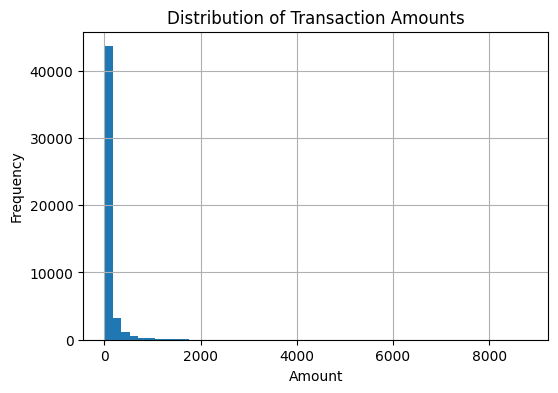

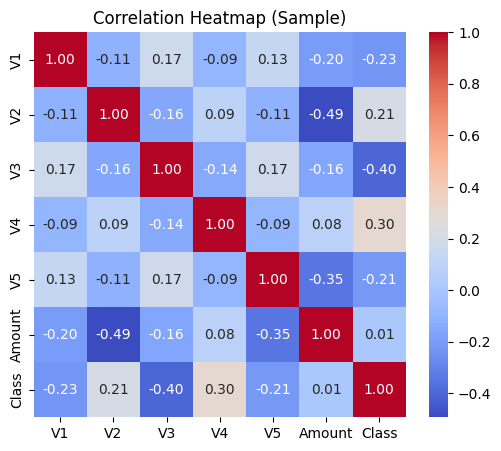

In [2]:
# Visualise the distribution of the 'Amount' feature
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,4))
df_sample['Amount'].hist(bins=50, ax=ax)
ax.set_title('Distribution of Transaction Amounts')
ax.set_xlabel('Amount')
ax.set_ylabel('Frequency')
plt.show()

# Correlation heatmap of a subset of features
import seaborn as sns
subset = df_sample[['V1','V2','V3','V4','V5','Amount','Class']]
corr = subset.corr()
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt='.2f', ax=ax, cmap='coolwarm')
plt.title('Correlation Heatmap (Sample)')
plt.show()

## Modify

We standardise the features to zero mean and unit variance.  This improves the convergence of many algorithms and ensures that no feature dominates solely due to scale differences.

### Expert Review & Recommendations
Other modifications could include dimensionality reduction (e.g. t‑SNE for visualisation) or feature selection.  Feature engineering is often the most impactful step in data mining.

In [3]:
# Prepare data for modelling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X = df_sample.drop(columns=['Class'])
y = df_sample['Class']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=1, stratify=y)

## Model

We employ a random forest classifier, which handles nonlinearities and interactions naturally.  Using 100 trees strikes a balance between performance and computational cost.

### Expert Review & Recommendations
Hyperparameter tuning (e.g. adjusting tree depth, minimum samples per leaf) and exploring alternative models (XGBoost, LightGBM) are recommended for production systems.

In [4]:
# Train a random forest classifier
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])
print(f'Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, ROC AUC: {roc_auc:.4f}')

Precision: 0.9385, Recall: 0.8243, F1: 0.8777, ROC AUC: 0.9779


## Assess

The random forest achieves high ROC AUC but precision and recall reveal the difficulty of catching rare events.  A confusion matrix inspection would show many false positives and some false negatives.

### Expert Review & Recommendations
Assessment should compare multiple models and incorporate business costs.  For example, missing a fraud (false negative) may cost more than investigating a false alert (false positive).  Cost‑sensitive learning can directly optimise for such trade‑offs.